## `hsc_randoms.ipynb` 

This notebook explains how we generate randoms for the HSC catalog. 

## Step 1 : Binning HSC sources on a healpix map

In [2]:
# imports
import fitsio as fio 
import numpy as np 
import healpy as hp
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import importlib
import tqdm

from numpy.lib import recfunctions as rfn
from astropy.table import Table, vstack
from pathlib import Path

# tools
import simtools as simt

In [3]:
# Some interface to get the buzzard catalog
importlib.reload(simt)
bc = simt.BuzzardCatalog(buzzard_index=4)
pix = 0
# testing the files are available
mag = bc.fetch_surveymag(pix=pix)
true = bc.fetch_truth(pix=pix)
tgt = bc.fetch_desi_target(pix=pix)
filters = np.loadtxt('filters.txt', dtype=str)
mag_index = list(filters).index('DECAM_i')

First thing to do is (according to Li et al, 2022) "In addition, we remove a region in GAMA09H with 132.5 <
ra < 140 [deg], 1.6 < dec < 5 [deg], containing an area of ∼20 deg^2." There's a reduction of 0% so we don't really care about that cut (already handled by "use_bmode_mask").

now, let's displace the HSC field temporarily into the Buzzard region to make our mock dataset; by sampling the footprint. We assert there's decent separation (a few degrees) and no overlap between the moved fields.
Values : 
- +80/35 RA/DEC for field 1
- +260/20 RA/DEC for field 2

In [4]:
# We move HSC coordinates to a location on the sky covered by Buzzard mocks (NW corner)
# We do field by field and join afterwards the catalogs. Once the field is moved, 
# sample on where buzzard actually is by limiting ra, dec coordinates

# first patch : 80, 35, second patch : 260, 20
offset_ra = 260
offset_dec = 20
patch_id = 2
# careful that we don't deal with dec > 90 and hsc goes up to dec ~45
# so this means we are limited to a dec offset of 30ish at most

hsc_tbl_all = fio.FITS(simt.HSC_CATALOG)
ra_tbl = hsc_tbl_all[1]['RA'].read()
dec_tbl = hsc_tbl_all[1]['DEC'].read()

# moving coordinates to the field where Buzzard is located
ra_all = (ra_tbl + offset_ra) % 360
dec_all = dec_tbl + offset_dec
# assert we are not going over dec > 90 in the process so that we don't shift the field outside bounds
assert np.sum(dec_all > 90) == 0
# limiting ourselves to the NW corner
# keeping the displaced HSC area that is in 
bds_mask = (0 < ra_all) & (ra_all < 180) & (0 < dec_all)
ra_hsc = ra_all[bds_mask]
dec_hsc = dec_all[bds_mask]

In [7]:
oid = hsc_tbl_all[1]['object_id'].read()
# check that we are not duplicating objects
assert len(oid) == len(np.unique(oid))
print(f'Number of objects in HSC : {len(oid)}')

Number of objects in HSC : 34407034


In [5]:
randbgs = fio.FITS(bc.fetch_desi_randoms(target='bgs'))
randlrg = fio.FITS(bc.fetch_desi_randoms(target='lrg'))
randelg = fio.FITS(bc.fetch_desi_randoms(target='elg'))

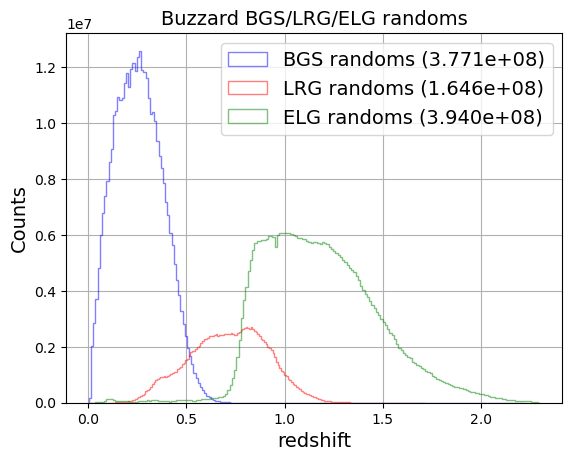

In [6]:
zbgs =  randbgs[1]['redshift'].read()
plt.hist(
    zbgs, 
    bins=200, 
    histtype='step', 
    color='blue', 
    alpha=0.5, 
    label=f'BGS randoms ({len(zbgs):.3e})'
    )
zlrg = randlrg[1]['redshift'].read()
plt.hist(
    zlrg, 
    bins=200, 
    histtype='step', 
    color='red', 
    alpha=0.5, 
    label=f'LRG randoms ({len(zlrg):.3e})'
    )
zelg = randelg[1]['redshift'].read()
plt.hist(
    zelg, 
    bins=200, 
    histtype='step', 
    color='green', 
    alpha=0.5, 
    label=f'ELG randoms ({len(zelg):.3e})'
    )
plt.xlabel('redshift', fontsize=14)
plt.grid()
plt.ylabel('Counts', fontsize=14)
plt.title('Buzzard BGS/LRG/ELG randoms', fontsize=14)
plt.legend(fontsize=14)

In [7]:
# clear memory
del zelg, zlrg, zbgs

### Assigning redshifts to the randoms

--------------------------------------

First step is to assign redshifts with a certain probability given the initial dataset.
We pick from the true redshift distribution of the sample and replace the redshift distribution of the randoms by picking in the sample.

In [8]:
## first off, desi randoms
# get the distributon
bgs_truthz_p = []
lrg_truthz_p = []
elg_truthz_p = []
for dtfp in tqdm.tqdm(bc.desi_tgt_files_pix):
    desi_tgts = fio.FITS(bc.fetch_desi_target(pix=pix))
    zdesi = desi_tgts[1]['z'].read()
    bgs_truthz_p.append(zdesi[desi_tgts[1]['isbgs_faint'].read() | desi_tgts[1]['isbgs_bright'].read()])
    lrg_truthz_p.append(zdesi[desi_tgts[1]['islrg'].read()])
    elg_truthz_p.append(zdesi[desi_tgts[1]['iselg'].read()])
bgs_truthz = np.concatenate(bgs_truthz_p)
lrg_truthz = np.concatenate(lrg_truthz_p)
elg_truthz = np.concatenate(elg_truthz_p)

100%|██████████| 204/204 [00:20<00:00, 10.09it/s]


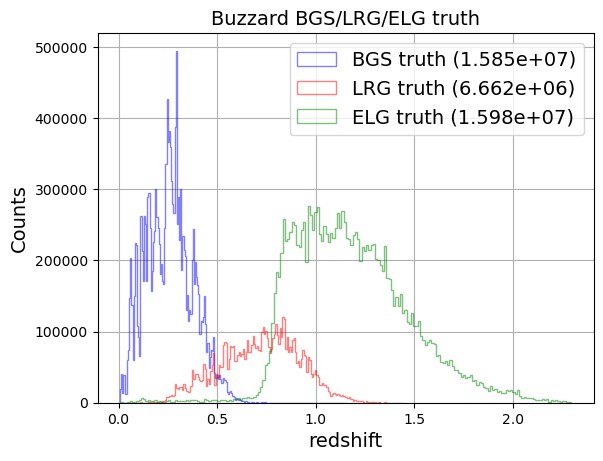

In [9]:
plt.hist(
    bgs_truthz, 
    bins=200, 
    histtype='step', 
    color='blue', 
    alpha=0.5, 
    label=f'BGS truth ({len(bgs_truthz):.3e})'
    )
plt.hist(
    lrg_truthz, 
    bins=200, 
    histtype='step', 
    color='red', 
    alpha=0.5, 
    label=f'LRG truth ({len(lrg_truthz):.3e})'
    )
plt.hist(
    elg_truthz, 
    bins=200, 
    histtype='step', 
    color='green', 
    alpha=0.5, 
    label=f'ELG truth ({len(elg_truthz):.3e})'
    )
plt.xlabel('redshift', fontsize=14)
plt.grid()
plt.ylabel('Counts', fontsize=14)
plt.title('Buzzard BGS/LRG/ELG truth', fontsize=14)
plt.legend(fontsize=14)

In [12]:
randdir = Path('randoms')
randdir.mkdir(exist_ok=True)

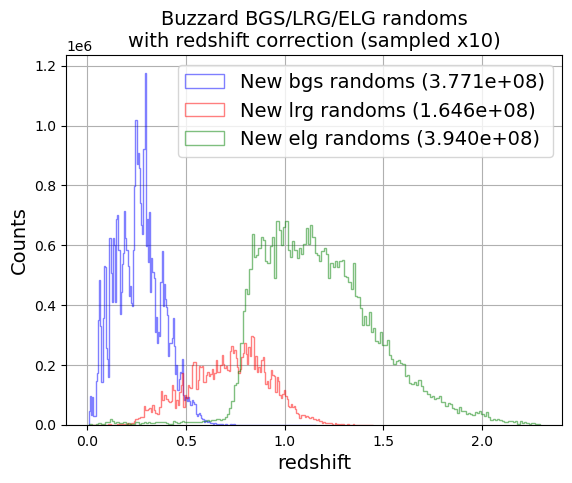

In [ ]:
seed = 123
gen = np.random.default_rng(seed=seed)

for tgt in ['bgs', 'lrg', 'elg']:
    rand = Table(fio.FITS(bc.fetch_desi_randoms(target=tgt))[1].read())
    if tgt == 'bgs':
        sample = bgs_truthz
    elif tgt == 'lrg':
        sample = lrg_truthz
    elif tgt == 'elg':
        sample = elg_truthz
    else:
        raise ValueError(f'Unknown target {tgt}')
    newz = gen.choice(sample, size=len(rand), replace=True)
    rand['redshift'] = newz
    plt.hist(
        newz[::10], 
        bins=200, 
        histtype='step', 
        color='blue' if tgt == 'bgs' else 'red' if tgt == 'lrg' else 'green', 
        alpha=0.5, 
        label=f'New {tgt} randoms ({len(newz):.3e})'
        )
    rand.write(randdir / f'{tgt}_randoms_zcorr.fits', overwrite=True)
    import gc
    gc.collect()
plt.xlabel('redshift', fontsize=14)
plt.grid()
plt.ylabel('Counts', fontsize=14)
plt.title('Buzzard BGS/LRG/ELG randoms\nwith redshift correction (sampled x10)', fontsize=14)
plt.legend(fontsize=14)

Plot the displaced HSC catalog

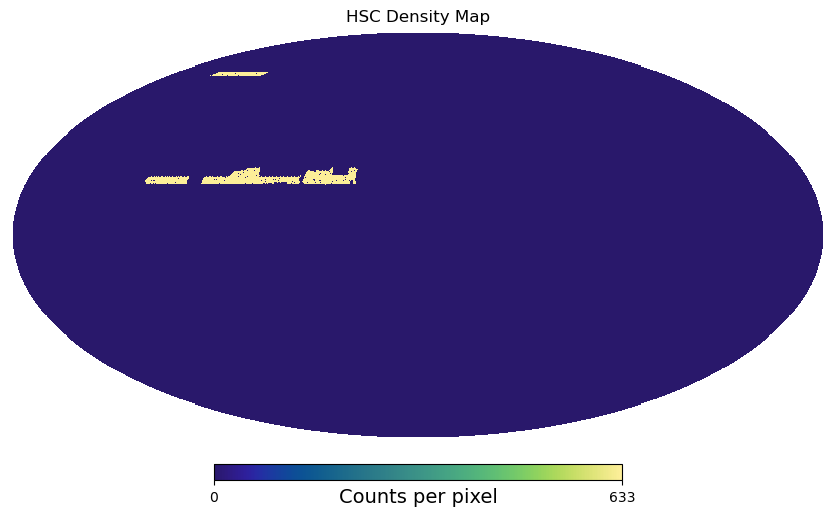

In [10]:
# very important : this determines local density of the map.
# in theory, we want it very high to accurately mimic survey sample
nside_hsc = 1024

npix_hsc = hp.nside2npix(nside_hsc)
theta = np.radians(90.0 - dec_hsc) 
phi = np.radians(ra_hsc)
hsc_pix_indices = hp.ang2pix(nside_hsc, theta, phi, nest=True)
hsc_hp_map = np.bincount(hsc_pix_indices, minlength=npix_hsc)

hp.mollview(
    hsc_hp_map,
    title="HSC Density Map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)

In [ ]:
importlib.reload(simt)
for tgt in tqdm.tqdm(['bgs', 'elg', 'lrg']):
    randall = Table.read(randdir / f'{tgt}_randoms_zcorr.fits')
    mask = simt.sample_on_hsc(
        active_hsc_pixels=np.unique(hsc_pix_indices),
        nside_hsc=nside_hsc,
        ra=randall['ra'],
        dec=randall['dec'],
    )
    print(f'Finished mask for {tgt} randoms')
    randall_on_hsc = randall[mask]
    randall_on_hsc['ra'] = (randall_on_hsc['ra'] - offset_ra) % 360
    randall_on_hsc['dec'] = randall_on_hsc['dec'] - offset_dec
    randall_on_hsc.write(randdir / 'patches' / f'{tgt}_ran_on_hsc{patch_id}_zcorr.fits', overwrite=True)

  0%|          | 0/3 [00:00<?, ?it/s]

Finished mask for bgs randoms


 33%|███▎      | 1/3 [01:14<02:29, 74.93s/it]

Finished mask for elg randoms


 67%|██████▋   | 2/3 [02:41<01:21, 81.83s/it]

Finished mask for lrg randoms


100%|██████████| 3/3 [03:18<00:00, 66.14s/it]


In [ ]:
## collate patches of randoms
for tgt in ['bgs', 'elg', 'lrg']:
    rand_all = vstack([Table.read(randdir / 'patches' / f'{tgt}_ran_on_hsc{i}_zcorr.fits') for i in range(1, 3)])
    rand_all.write(
        randdir / 
        # rename targets to BGS_ANY, ELGnotqso, LRG
        f"{('BGS_ANY' if tgt == 'bgs' else 'ELGnotqso' if tgt == 'elg' else 'LRG' if tgt == 'lrg' else '')}_ran_hsc_zcorr.fits", 
        overwrite=True
        )

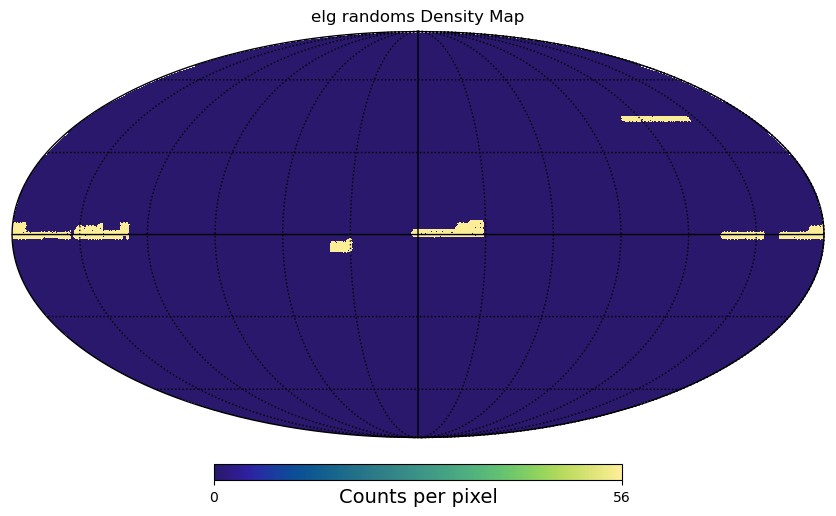

In [19]:
# plot the randoms to assert they are on the correct fields
tgt = 'elg'
randdesi_on_hsc = fio.FITS(randdir / f'{tgt}_ran_hsc_zcorr.fits')[1].read()[::4]
npix = hp.nside2npix(nside_hsc)
hp_desi_randoms = np.zeros(npix)
theta = np.radians(90.0 - randdesi_on_hsc['dec'])
phi = np.radians(randdesi_on_hsc['ra'])
desi_pix_indices = hp.ang2pix(nside_hsc, theta, phi, nest=True)
hp_desi_randoms = np.bincount(desi_pix_indices, minlength=npix)

hp.mollview(
    hp_desi_randoms,
    title=f"{tgt} randoms Density Map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)
hp.graticule()

# HSC Randoms

-----------------

Now, let's make randoms for HSC. Strategy is very similar. We just have to match HSC's redshift distribution.
For this we can simply use the redshift distribution of the simulated HSC catalog and resample redshifts from the merged random catalogs.

In [20]:
hscsim = fio.FITS(
    Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/v2/hscy3_sim_v2.fits')
    )

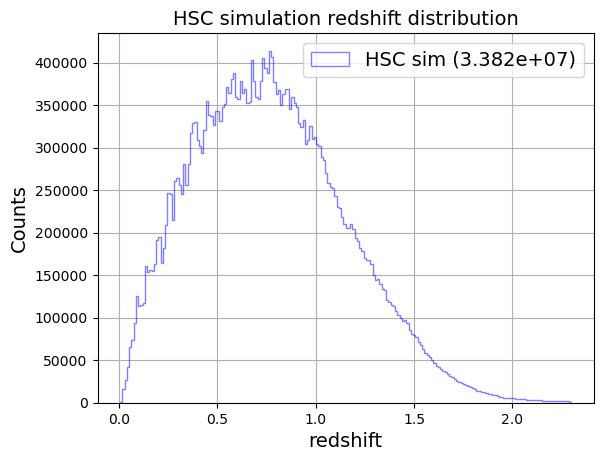

In [22]:
zsim = hscsim[1]['Z'].read()
plt.hist(
    zsim, 
    bins=200, 
    histtype='step', 
    color='blue', 
    alpha=0.5, 
    label=f'HSC sim ({len(zsim):.3e})'
    )
plt.title('HSC simulation redshift distribution', fontsize=14)
plt.xlabel('redshift', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend(fontsize=14)
plt.grid()

In [23]:
randcat = vstack(
    [Table.read(randdir / f'{tgt}_ran_hsc_zcorr.fits') for tgt in ['bgs', 'elg', 'lrg']]
    )

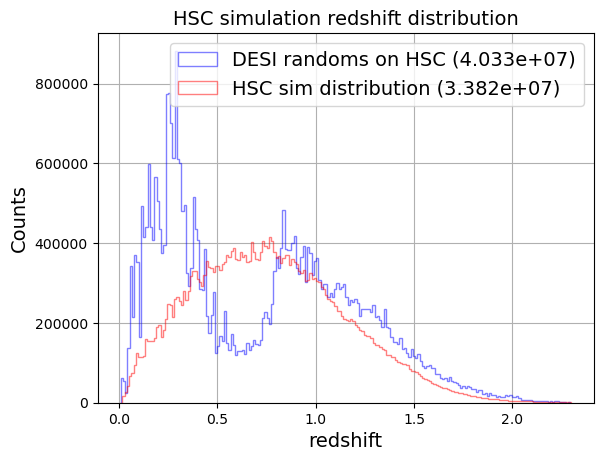

In [26]:
plt.hist(
    randcat['redshift'], 
    bins=200, 
    histtype='step', 
    color='blue', 
    alpha=0.5, 
    label=f'DESI randoms on HSC ({len(randcat):.3e})'
    )
plt.hist(
    zsim, 
    bins=200, 
    histtype='step', 
    color='red', 
    alpha=0.5, 
    label=f'HSC sim distribution ({len(zsim):.3e})'
    )
plt.title('HSC simulation redshift distribution', fontsize=14)
plt.xlabel('redshift', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend(fontsize=14)
plt.grid()

In [28]:
seed = 123
gen = np.random.default_rng(seed=seed)
randcat['redshift'] = gen.choice(
    zsim, 
    size=len(randcat), 
    replace=True
    )
randcat.write(
    randdir / 'hsc_randoms_zcorr.fits', 
    overwrite=True
    )